# Model Inputs

"ml_input.csv" can be retrieved from 03-Sample-Prep (single dataframe w/ train and test sets)

### Packages

In [1]:
import pandas as pd
import numpy as np
import os

import umap

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn import metrics

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import plotly.express as px
import plotly.graph_objects as go

In [23]:
DATA_DIR = "~/Desktop/Projects/media-prediction/"
RANDOM_SEED = 26

### Dataset

In [3]:
# Loading output dataframe from data.ipynb
df = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

# Filter non-specific ec numbers (e.g., 1.1.1,-)
filter = df["ec"].str.contains("-")
df = df[~filter]

# Format for machine learning
df = df[["taxon_id", "media_id", "ec"]].value_counts().reset_index()
df = df.pivot(index=["taxon_id", "media_id"], columns="ec", values="count")
df = df.fillna(0.0).reset_index()

# Filtering into training and test sets (database set vs. MAGs)
bins = df["media_id"].str.contains("unknown")
df_train = df[~bins]
df_test = df[bins]

df.head()

ec,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Split dataset

In [4]:
TARGET = "media_id" # target label

bins1 = df_train["media_id"].str.contains("unknown")
bins2 = df_test["media_id"].str.contains("unknown")
df_train 

# Test case with MAGs
X_train = df_train.drop(["taxon_id", "media_id"], axis=1)
y_train = df_train[TARGET] 
X_test = df_test.drop(["taxon_id", "media_id"], axis=1)
y_test = df_test[TARGET]

# Model

In [5]:
model = umap.UMAP(      
        metric="euclidean",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=40, 
        n_neighbors=62, 
        min_dist=0 
        )

### Fit and transform

In [6]:
X_train_transformed = model.fit_transform(X_train) # fit pipeline and transform training data
X_test_transformed = model.transform(X_test) # transform test data

### Cluster

In [7]:
# Cluster
clusterer = KMeans(n_clusters=80, random_state=RANDOM_SEED)
cluster_labels = clusterer.fit_predict(X_train_transformed)
test_clusters = clusterer.predict(X_test_transformed)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


### Metrics

In [8]:
# UMAP and clustering performance
silhouette_avg = silhouette_score(X_train_transformed, cluster_labels)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

80 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.6810234189033508


# Classifier

In [9]:
y2_train = cluster_labels
y2_test = test_clusters

### Random Forest

In [10]:
rfc = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

rfc.fit(X_train_transformed, y2_train)
print(rfc.predict(X_test_transformed))

[63 29 47  0 47  0 74 47 47  0 47 47 29 74 37  0 47 57 57 69 74 51 69 47
 47 47 63  0 47 37 54 57  0  0 69 47 69 47 47 47 29 69 47 69 69 29 47 47
 47 51 47  0 47 47 51 69 57 57  0  0 74 47 29 57 47  0 47 47 29 47 51 47
  1  1  0 47 47 47 47 74 47 47 54 47  0 47 29 47 57 57 47 69 47 47 47 47
  1  0 69 47  0  0 63 29 47 47 47 47  0  0  0 47 47 47 74 47 47 47 51 29
 51 63 63  1  0 47  0 54 44 74 51 29 69 47  0 39 69 47  0  0 57 74 57 57
 47  0 51 29 57 51 69 69 74 69 47 47  0 47  1 74 37 47  0 51  0  0 47  0
 74 37  1  0 13 29 29 51 63 47 47 47 47 29 37 47 51 47 47 29 74 47 69 51
  1 47  0 29 47  0 47 47 54 69  3 51  1 47 74 47 29 51  0 47  0 47 47 47
 69  1 51  1 69 51  0 44  0  0 29  0 47 29 20  0 74  0 47 47  0 69  0 29
 47 47 69 47  0 61 47]


In [11]:
report = classification_report(
    y_true=y2_test,
    y_pred=rfc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=rfc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("RF ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.60      1.00      0.75         6
           3       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          20       1.00      0.50      0.67         2
          29       0.90      1.00      0.95        18
          37       1.00      1.00      1.00         5
          39       1.00      1.00      1.00         1
          44       0.50      1.00      0.67         1
          46       0.00      0.00      0.00         1
          47       1.00      0.83      0.91       105
          51       0.53      0.90      0.67        10
          54       1.00      1.00      1.00         4
          57       1.00      0.75      0.86        16
          61       1.00      1.00      1.00         1
          63       1.00      1.00      1.00         6
          69       0.86      1.00      0.92        18
          74       0.50    

### Nearest Neighbors

In [12]:
knc= KNeighborsClassifier(n_neighbors=1)
knc.fit(X_train_transformed, cluster_labels)
distances, indices = knc.kneighbors(X_test_transformed)

print(knc.predict(X_test_transformed))

[63 29 47  0 47  0 74 47 47  0 47 47 29 74 37  0 47 57 57 69 74 51 69 47
 47 47 63  0 47 37 54 57  0  0 69 47 69 47 51 47 29 69 47 69 74 29 47 47
 47 51 47  0 47 47 51 69 57 57  0  0 74 47 29 57 47  0 47 47 29 47 47 47
  1 57  0 47 47 47 47 74 51 47 54 47  0 47 29 47 57 57 47 47 47 47 47 47
 57  0 69 47  0  0 63 29 47 47 47 51  0  0  0 47 47 47 74 47 47 47 51 29
 47 63 63  1  0 47  0 54 44 74 51 29 69 47  0 39 69 47  0  0 57 47 57 57
 47  0 47 29 57 47 74 69 74 69 47 47  0 47  1 74 37 47  0 51  0  0 47  0
 74 37  1  0 13 29 47 51 63 47 47 47 47 29 37 47 51 47 47 29 20 47 69 51
 57 47  0 29 47  0 47 47 54 69  3 51 54 47 74 47 29 51  0 47  0 47 47 47
 47  1 47  1 69 51  0 46  0  0 29  0 47 29 20  0 74  0 47 47  0 69  0 47
 47 47 69 47  0 61 47]


In [13]:
report = classification_report(
    y_true=y2_test,
    y_pred=knc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=knc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("KNN ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.83      0.83      0.83         6
           3       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         2
          29       0.94      0.94      0.94        18
          37       1.00      1.00      1.00         5
          39       1.00      1.00      1.00         1
          44       1.00      1.00      1.00         1
          46       1.00      1.00      1.00         1
          47       0.98      0.88      0.92       105
          51       0.53      0.80      0.64        10
          54       0.80      1.00      0.89         4
          57       1.00      0.94      0.97        16
          61       1.00      1.00      1.00         1
          63       1.00      1.00      1.00         6
          69       0.94      0.89      0.91        18
          74       0.50    

# Outputs

### Train, clustering labels

In [14]:
# Training data
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
train_df['Set'] = 'Training'
train_df['Target'] = y_train
train_df['KMeans Cluster'] = cluster_labels
train_df['taxon_id'] = df_train["taxon_id"]

# Media cluster labels
media_clusters = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "media-clusters.csv"))
target_label_mapping = dict(zip(media_clusters['media_id'], media_clusters['Media Cluster']))
train_df['Media Cluster'] = train_df['Target'].map(target_label_mapping)

#train_df.to_csv(os.path.join(DATA_DIR, "model", "train-output.csv"), index=False)
train_df.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 36,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,taxon_id,Media Cluster
0,10.019588,11.712086,9.899593,-12.785728,18.032261,7.258595,8.687618,17.642654,4.672285,-7.041827,...,5.611942,2.900656,4.944120,5.144392,1.457258,Training,J346,23,100.0,6.0
1,6.635316,0.935035,3.068260,7.683230,8.687971,22.017916,4.532227,33.582054,5.222730,-1.351588,...,3.755361,5.819689,10.834550,1.976926,4.767097,Training,J386,13,100.0,3.0
2,6.343478,0.963707,2.307567,7.085051,7.459273,21.217720,5.748045,32.970108,4.461621,-2.811620,...,4.400699,4.783994,10.402700,1.801262,4.431127,Training,J233,0,100225.0,NaN
3,0.051884,-28.283895,1.973101,25.889019,3.873154,56.852692,-36.668049,-2.147321,11.118980,32.457203,...,6.793017,6.300559,-4.493289,13.136193,1.912981,Training,J22,49,1002526.0,9.0
4,7.171787,1.335306,3.495087,7.093310,8.736001,21.424393,4.202975,31.338734,4.901442,-1.712550,...,4.018287,5.056476,10.690995,1.922635,5.555188,Training,1a,20,1004166.0,9.0


### Test, classifier labels

In [15]:
# Test data
test_df = pd.DataFrame(X_test_transformed, columns=[f"Component {i+1}" for i in range(X_test_transformed.shape[1])])
test_df['Set'] = 'Test'
test_df['Target'] = list(df_test['media_id'])
test_df['KMeans Cluster'] = test_clusters
test_df['taxon_id'] = list(df_test['taxon_id'])

# Add classifier labels 
test_df["KNN Classify"] = knc.predict(X_test_transformed)
test_df["RF Classify"] = rfc.predict(X_test_transformed)

#test_df.to_csv(os.path.join(DATA_DIR, "model", "test-output.csv"), index=False)
test_df.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,taxon_id,KNN Classify,RF Classify
0,0.027597,-28.327099,1.249199,25.385933,3.787880,56.907963,-35.169094,-1.452716,10.373749,32.447216,...,5.587649,-4.119488,14.277275,1.808210,Test,unknown,63,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,63,63
1,6.654238,1.502301,3.118655,7.186655,8.953646,21.785292,3.964489,32.284000,5.113863,-1.651399,...,5.215433,10.792274,1.829895,5.069899,Test,unknown,29,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,29,29
2,6.723119,1.454971,3.181690,7.175318,8.860973,21.686432,4.047646,32.098873,5.054540,-1.707458,...,5.148512,10.773395,1.833236,5.158617,Test,unknown,47,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,47,47
3,6.376501,1.070349,2.469510,7.170621,7.737154,21.416361,5.451352,33.079201,4.494258,-2.687729,...,5.043266,10.514274,1.815532,4.482202,Test,unknown,0,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,0,0
4,6.816277,1.298532,3.172935,7.331283,8.699174,21.625530,4.357909,31.998154,5.011365,-1.729759,...,5.043253,10.675090,1.862300,5.198308,Test,unknown,47,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,47,47


### ID nearest neighbors

In [16]:
# Add nearest neighbor indices to the test dataframe
knn_df = test_df.copy()
knn_df = knn_df.rename(columns={"KMeans Cluster": "Test Cluster"})
neighbors = pd.DataFrame(indices) # Indices of nearest neighbors from the training set
knn_df['indices'] = neighbors[neighbors.columns[0:]].apply(lambda x: ';'.join(x.dropna().astype(str)), axis=1)
knn_df["indices"] = knn_df["indices"].str.split(';')
knn_df = knn_df.explode("indices")

# Add original indices as a column for the train dataframe
train_index = train_df.copy()
train_index = train_index.rename(columns={"KMeans Cluster": "Train Cluster"})
train_index["indices"] = df_train.index
train_index["indices"] = train_index["indices"].astype(str)

# Merge to label nearest neighbors
left = knn_df.copy()
right = train_index[["indices", "Target", "taxon_id", "Media Cluster"]]
right = right.rename(columns={"Target": "neighbor_media_id", "taxon_id": "neighbor_taxon_id", "Cluster": "neighbor_cluster"})
merged = pd.merge(left, right, on="indices", how="left")

#merged.to_csv(os.path.join(DATA_DIR, "model", "ml-model-output.csv"), index=False)
merged.head()

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Set,Target,Test Cluster,taxon_id,KNN Classify,RF Classify,indices,neighbor_media_id,neighbor_taxon_id,Media Cluster
0,0.027597,-28.327099,1.249199,25.385933,3.787880,56.907963,-35.169094,-1.452716,10.373749,32.447216,...,Test,unknown,63,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,63,63,6597,220a,51197.0,15.0
1,6.654238,1.502301,3.118655,7.186655,8.953646,21.785292,3.964489,32.284000,5.113863,-1.651399,...,Test,unknown,29,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,29,29,7921,J237,75385.0,5.0
2,6.723119,1.454971,3.181690,7.175318,8.860973,21.686432,4.047646,32.098873,5.054540,-1.707458,...,Test,unknown,47,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,47,47,1740,J14,1583098.0,19.0
3,6.376501,1.070349,2.469510,7.170621,7.737154,21.416361,5.451352,33.079201,4.494258,-2.687729,...,Test,unknown,0,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,0,0,4656,1076b,28903.0,19.0
4,6.816277,1.298532,3.172935,7.331283,8.699174,21.625530,4.357909,31.998154,5.011365,-1.729759,...,Test,unknown,47,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,47,47,339,J22,113288.0,9.0


### Feature importance

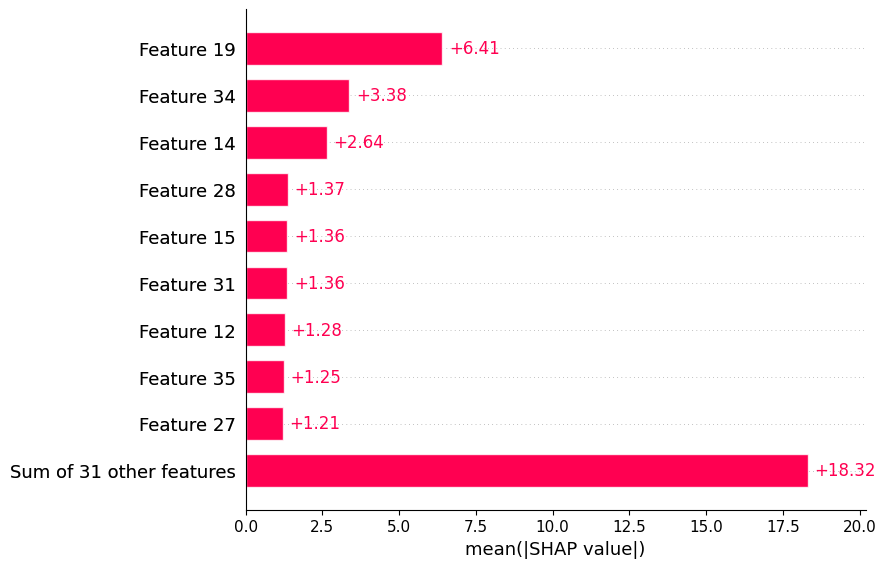

In [17]:
import xgboost
import shap

XG_train = X_train_transformed
yG_train = cluster_labels
XG_test = X_test_transformed
yG_test = test_clusters

model = xgboost.XGBRegressor().fit(XG_train, yG_train)

explainer = shap.Explainer(model)
shap_values = explainer(XG_train) #XG_test

shap.plots.initjs()

#shap.plots.beeswarm(shap_values) #, max_display=40
#shap.plots.waterfall(shap_values[0])
#shap.plots.force(shap_values[:500])
#shap.plots.bar(shap_values.abs.max(0))

shap.plots.bar(shap_values)

# Visualization

### n dimensions

In [18]:
# Highest-importance features (set var to easily change vis)
dim1 = "Component 36" # 31 38
dim2 = "Component 23" # 13 33

# Plot the training points
fig = px.scatter(
    data_frame = train_df,
    x = dim1,
    y = dim2, 
    color = "Media Cluster",
    hover_data = ["taxon_id", "Target", "KMeans Cluster"],
    opacity = 0.3
) 

# Add the test points as a scatter trace
fig.add_trace(
    go.Scatter(
        x=test_df[dim1],  # x coordinates
        y=test_df[dim2],  # y coordinates
        mode='markers',
        marker=dict(
            color='black',  
            size=5,  
            opacity=1.0 
        ),
        text=test_df["taxon_id"]  # marker hover text
    )
)

# Opacity slider
steps = []
for i in range(11):  # 0 to 1 in steps of 0.1
    step = dict(
        method="restyle",
        args=[{"marker.opacity": [i/20]}, [0]],  # Adjust opacity of the first trace only
        label=str(i/20)
    )
    steps.append(step)
sliders = [dict(
    active=3,  # initial value corresponding to opacity=0.3
    currentvalue={"prefix": "Opacity: "},
    pad={"t": 50},
    steps=steps
)]

# Make pretty
fig.update_coloraxes(showscale=False)
fig.update_layout(
    sliders=sliders,
    title="Fenix21 (Global Structure)", # Local => limit axis ranges
    template="plotly_white",
    showlegend=False,
    width=500, 
    height=500 
)

#fig.update_yaxes(range=[2.25, 4.25])
#fig.update_xaxes(range=[2, 8])

fig.show()

In [19]:
# For thesis:

fig = px.scatter(
    data_frame = train_df,
    x = dim1,
    y = dim2, 
    color = "KMeans Cluster",
    hover_data = ["taxon_id", "Target", "Media Cluster"],
    opacity = 0 #0.3 #Toggle training points
) 

fig.add_trace(
    go.Scatter(
        x=test_df[dim1], 
        y=test_df[dim2], 
        mode='markers',
        marker=dict(color='black', size=5, opacity=1.0)
    )
)

fig.update_coloraxes(showscale=False)
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    width=500, 
    height=500
)

# Toggle for global/local structure
#fig.update_yaxes(range=[2.25, 4.25])
#fig.update_xaxes(range=[2, 8])

fig.show()

# Prediction

## Prediction dataframes / statistics

In [20]:
predictor = merged.copy()
predictor = predictor.drop(predictor.iloc[:,0:42], axis=1)
predictor = predictor.drop('indices', axis=1)

#predictor.to_csv("~/Desktop/media_mapping/prediction_test_v3/TEST20.csv", index=False) # save under different names for further analysis with each seed
predictor.head()

,Test Cluster,taxon_id,KNN Classify,RF Classify,neighbor_media_id,neighbor_taxon_id,Media Cluster
0,63,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,63,63,220a,51197.0,15.0
1,29,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,29,29,J237,75385.0,5.0
2,47,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,47,47,J14,1583098.0,19.0
3,0,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,0,0,1076b,28903.0,19.0
4,47,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,47,47,J22,113288.0,9.0


In [21]:
df = predictor[["taxon_id", "Test Cluster", "KNN Classify", "RF Classify", "neighbor_taxon_id", "neighbor_media_id", "Media Cluster"]]
df = df.rename(columns={
    "Test Cluster": "KM",
    "KNN Classify": "KN", 
    "RF Classify": "RF",
    "neighbor_media_id": "KN Neighbor Media",
    "neighbor_taxon_id": "KN Neighbor ID"
})
df.head()

,taxon_id,KM,KN,RF,KN Neighbor ID,KN Neighbor Media,Media Cluster
0,KBase_derived_Bin.001.fastaBA_F_extracted_bins...,63,63,63,51197.0,220a,15.0
1,KBase_derived_Bin.001.fastaBA_S_extracted_bins...,29,29,29,75385.0,J237,5.0
2,KBase_derived_Bin.001.fastaCF_F_extracted_bins...,47,47,47,1583098.0,J14,19.0
3,KBase_derived_Bin.001.fastaCG_S_extracted_bins...,0,0,0,28903.0,1076b,19.0
4,KBase_derived_Bin.001.fastaFE_F_extracted_bins...,47,47,47,113288.0,J22,9.0


## Single-neighbor test case

In [24]:
# Search for media with trace element solutions

media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #mediadive-complete.csv source?

trace_element = media_df["sub_solutions"].str.contains("trace")
trace_media = media_df[trace_element]
te_list = trace_media["media_id"].to_list()

print(len(trace_media))
trace_media.head()

52


,media_id,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml
133,1360,"[2740, 155, 5980]","['Main sol. 1360', ""Allen's trace element solu...","['NaCl', 'MgCl2 x 6 H2O', 'KCl', '(NH4)2SO4', ...","[43, 79, 61, 27, 11, 8, 7, 82, 23, 1249, 1852,...","[26.0435, 1.48368, 0.445104, 1.28586, 0.276954...",[[{'step': 'Dissolve ingredients (except sulfu...,"[""Allen's trace element solution"", ""Wolin's vi...","[155, 5980]","[10, 1]"
141,1714,"[3551, 155, 5980]","['Main sol. 1714', ""Allen's trace element solu...","['(NH4)2SO4', 'KH2PO4', 'Na2S2O3 x 5 H2O', 'Mg...","[27, 11, 65, 8, 7, 16, 770, 260, 4, 36, 196, 3...","[0.197824, 2.96736, 2.4728, 0.49456, 0.24728, ...","[[{'step': 'Dissolve ammonium sulfate, potassi...","[""Allen's trace element solution"", ""Wolin's vi...","[155, 5980]","[10, 1]"
144,J1004,"[5040, 5041, 5042, 5043, 5044]","['Main sol. J1004', 'Basic FWM solution', 'Mod...","['NaCl', 'KCl', 'MgCl2 x 6 H2O', 'KH2PO4', 'Ca...","[43, 61, 79, 11, 7, 4, 1230, 55, 42, 438, 68, ...","[0.983284, 0.491642, 0.393314, 0.196657, 0.098...","[None, [{'recipe_order': 7, 'step': 'Autoclave...","['Modified trace element mixture', 'Vitamin so...","[5042, 5043, 5044]","[1, 1, 10]"
170,J167,"[3821, 3822]","['Main sol. J167', 'SL-6 trace element solution']","['KH2PO4', 'KCl', 'NH4Cl', 'MgSO4 x 7 H2O', 'C...","[11, 61, 42, 8, 190, 43, 839, 16, 101, 32, 3, ...","[1, 1, 1, 0.24, 0.17, 200, 1, 5, 5, 5, 20, 0.1...",[[{'step': 'Add components except Na2CO3 to di...,['SL-6 trace element solution'],[3822],[1]
183,C56,"[6047, 6204, 6199]","['Mail sol. C56', 'Iron-EDTA', 'PII trace meta...","['Na2 beta-glycerol PO4 x 5 H2O', 'NaNO3', 'Vi...","[2358, 187, 18, 666, 46, 418, 3, 247, 34, 34, ...","[None, None, None, None, None, None, 15, 0.7, ...",[[{'step': 'Prepare the following primary stoc...,"['Iron-EDTA', 'PII trace metals']","[6204, 6199]","[100, 200]"


In [27]:
# Find prediction results for those media

df = pd.read_csv(os.path.join(DATA_DIR, "data", "TEST1.csv"))

df = df.rename(columns={"neighbor_media_id": "media_id"})
filter = df["media_id"].isin(te_list)
df = df[filter]

print(len(df))

prediction = pd.merge(left=df, right=trace_media, on="media_id", how="left")

print(len(prediction))
prediction.head()

0
0


,Test Cluster,taxon_id,KNN Classify,RF Classify,media_id,neighbor_taxon_id,Media Cluster,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml


Note: it appears none of the suggested neighboring media currently have trace element solutions included as sub-solutions, regardless, let's take our main outlier as a test case:

In [28]:
df = pd.read_csv(os.path.join(DATA_DIR, "data", "TEST1.csv"))
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"

df = df.rename(columns={"neighbor_media_id": "media_id"})
boi = df["taxon_id"].str.contains("Bin.003.fastaCG_F")
data = df[boi]

prediction = pd.merge(left=data, right=media_df, on="media_id", how="left")

print(len(prediction))
prediction.head()

1


,Test Cluster,taxon_id,KNN Classify,RF Classify,media_id,neighbor_taxon_id,Media Cluster,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml
0,67,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,67,67,J363,2499157.0,NaN,[4084],['Main sol. J363'],"['Salt Solution I', 'Salt Solution II', 'Trypt...","[1143, 1144, 124, 16, 5, 214, 171, 199, 1852, ...","[None, None, 9.96016, 4.98008, 0.249004, 0.249...",[[{'step': 'Adjust pH to 6.7. Prepare medium a...,[],[],[]


Let's map some cofactor concentrations:

In [29]:
# Load ec and cofactor info

trco = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
trco = trco[["Query EC", "CofactorExtracted", "Fe-S cluster", "CofactorFinal"]]
trco = trco.rename(columns={"Query EC": "ec"})

trta = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

cfdf = pd.merge(left=trta, right=trco, on="ec", how="left")

cfdf.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
0,1a,Comamonas testosteroni,1886637.0,uniprot,2.6.1.1,NaN,NaN,NaN
1,1a,Comamonas testosteroni,1886637.0,uniprot,4.1.1.12,NaN,NaN,NaN
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
4,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.13.23,NaN,NaN,NaN


In [31]:
# Focus on metals / trace elements:
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv")) #TODO: metals list as a given
meli = metals["Metals"].to_list()
filter = cfdf["CofactorFinal"].isin(meli)
meco = cfdf[filter]

meco.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
7,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,Ca(2+),False,Ca
8,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,heme c,False,Fe
15,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.12.15,Fe cation,False,Fe


Now: need a list of each trace element solution utilizing these ~90+ cofactors, and then 1) map the distributions of these concentrations (linear regression, just plot means, distributions, etc.), align these values with the "CofactorFinal", and attempt for a given test case to be able to suggest concentrations based on the EC numbers present (similar to Method 1, but needs refinement)

In [32]:
comp = meco[["media_id", "taxon_id", "source", "ec", "CofactorFinal"]]
comp = comp.dropna()

# Filters
bins = comp["source"].str.contains("KBase") # Separate MAGs from training database
boi = comp["taxon_id"].str.contains("Bin.003.fastaCG_F") # Isolate a single test MAG

co = comp[~bins]
ct = comp[bins]
test = comp[boi]

#Create, merge, format counts 
coct = co["CofactorFinal"].value_counts().reset_index()
sum1 = coct["count"].sum(axis=0)
coct['ratio1'] = coct['count'].div(sum1)
coct = coct.rename(columns={"count": "count1"})

ctct = ct["CofactorFinal"].value_counts().reset_index()
sum2 = ctct["count"].sum(axis=0)
ctct['ratio2'] = ctct['count'].div(sum2)
ctct = ctct.rename(columns={"count": "count2"})

tect = test["CofactorFinal"].value_counts().reset_index()
sum3 = tect["count"].sum(axis=0)
tect['ratio3'] = tect['count'].div(sum3)
tect = tect.rename(columns={"count": "count3"})

cf_df = pd.merge(left=coct, right=ctct, on="CofactorFinal", how="left")
cf_df = pd.merge(left=cf_df, right=tect, on="CofactorFinal", how="left")
cf_df = cf_df.fillna(0)

x = cf_df["count1"].sum(axis=0)
y = cf_df["count2"].sum(axis=0)
z = cf_df["count3"].sum(axis=0)
print(x, "annotated bin cofactors", y, "annotated database cofactors")


# Relabel cofactors to group organic
relabeled_cofactors = cf_df.copy()
dictionary = {
    "a monovalent": "UM",
    "metal": "UM"
}

for key in dictionary.keys():
    relabeled_cofactors["CofactorFinal"] = relabeled_cofactors["CofactorFinal"].str.replace(key, dictionary[key])

relabeled_cofactors = relabeled_cofactors.groupby(['CofactorFinal'])[['count1', 'ratio1', 'count2', 'ratio2', 'count3', 'ratio3']].sum().reset_index()
relabeled_cofactors = relabeled_cofactors.sort_values(['count1'], ascending=[False])


# Format for visualization
df1 = relabeled_cofactors[["CofactorFinal", "count1", "ratio1"]]
df2 = relabeled_cofactors[["CofactorFinal", "count2", "ratio2"]]
df3 = relabeled_cofactors[["CofactorFinal", "count3", "ratio3"]]

df1 = df1.rename(columns={"count1": "ct", "ratio1": "ra"})
df2 = df2.rename(columns={"count2": "ct", "ratio2": "ra"})
df3 = df3.rename(columns={"count3": "ct", "ratio3": "ra"})

df1["Set"] = "Training"
df2["Set"] = "Test"
df3["Set"] = "Bin 003 CG_F"

frames = df1, df2, df3
df = pd.concat(frames)
df.head()

1683059 annotated bin cofactors 95814.0 annotated database cofactors


,CofactorFinal,ct,ra,Set
7,Mg,433561.0,0.257603,Training
16,Zn,295693.0,0.175688,Training
4,Fe,234241.0,0.139176,Training
8,Mn,174574.0,0.103724,Training
0,Ca,133125.0,0.079097,Training


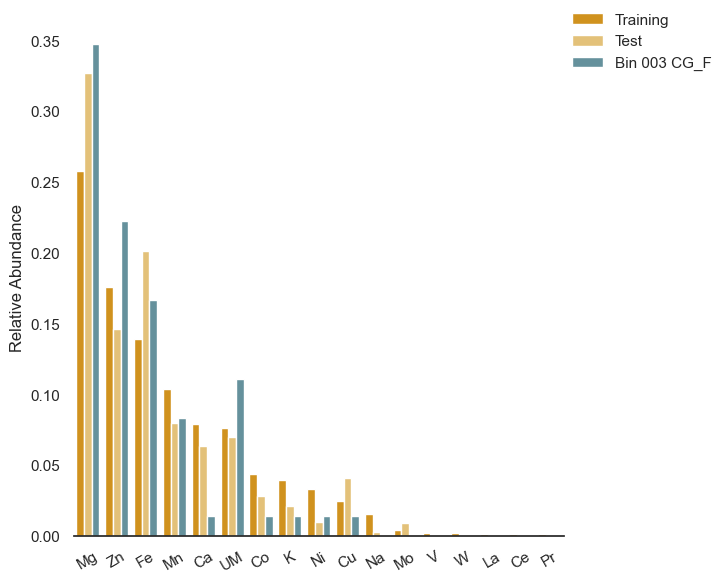

In [33]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#ee9b00", "#f5c767", "#5c96a5"]

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=df, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Abundance")
g.tick_params(axis='x', rotation=30)
g.legend.set_loc("upper right")
g.legend.set_title("")